<a href="https://colab.research.google.com/github/edent4313-star/climate-challenge-week0/blob/eda.sudan/eda_sudan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving sudan.csv to sudan.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("sudan.csv")

# Add country
df["Country"] = "sudan"

# Date parsing
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Month
df["Month"] = df["Date"].dt.month

# Replace -999
df.replace(-999, np.nan, inplace=True)

# Duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

# Summary
display(df.describe())

# Missing values
missing = pd.DataFrame({
    "Null Count": df.isna().sum(),
    "Percent": df.isna().mean()*100
})
display(missing.sort_values("Percent", ascending=False))

Duplicates: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


,Null Count,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [4]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = np.abs(df[cols].apply(zscore, nan_policy='omit'))
outliers = (z > 3).any(axis=1)

print("Outlier rows:", outliers.sum())

Outlier rows: 84


In [5]:
df = df[df.isna().mean(axis=1) <= 0.30]
df = df.fillna(method="ffill")

/tmp/ipykernel_5551/3824819270.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [6]:
df.to_csv("ethiopia_clean.csv", index=False)

/tmp/ipykernel_5551/2328911543.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df.resample("M", on="Date")["T2M"].mean()


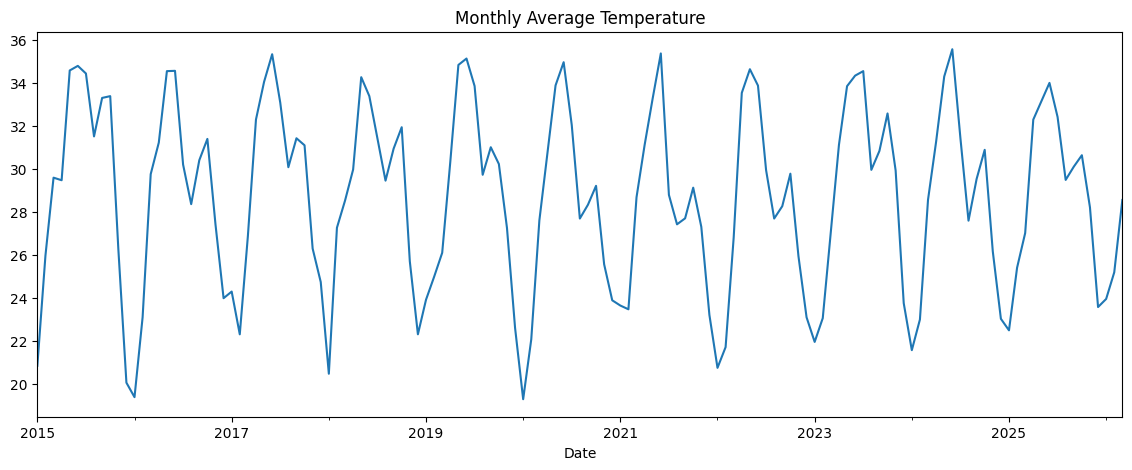

In [7]:
monthly_temp = df.resample("M", on="Date")["T2M"].mean()

plt.figure(figsize=(14,5))
monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.show()

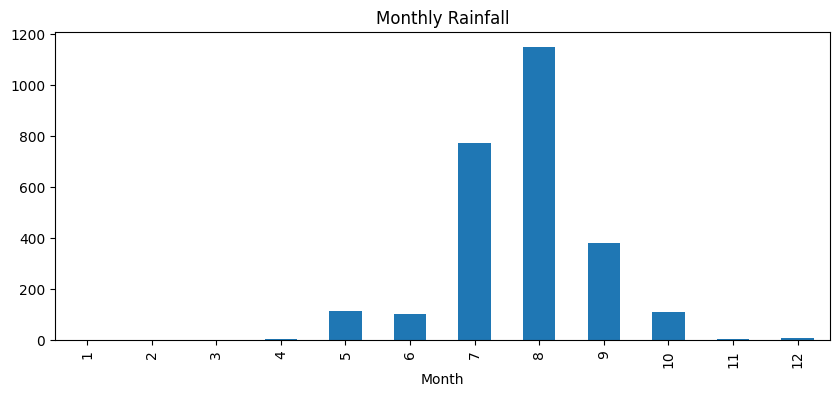

In [8]:
rain = df.groupby("Month")["PRECTOTCORR"].sum()

rain.plot(kind="bar", figsize=(10,4))
plt.title("Monthly Rainfall")
plt.show()

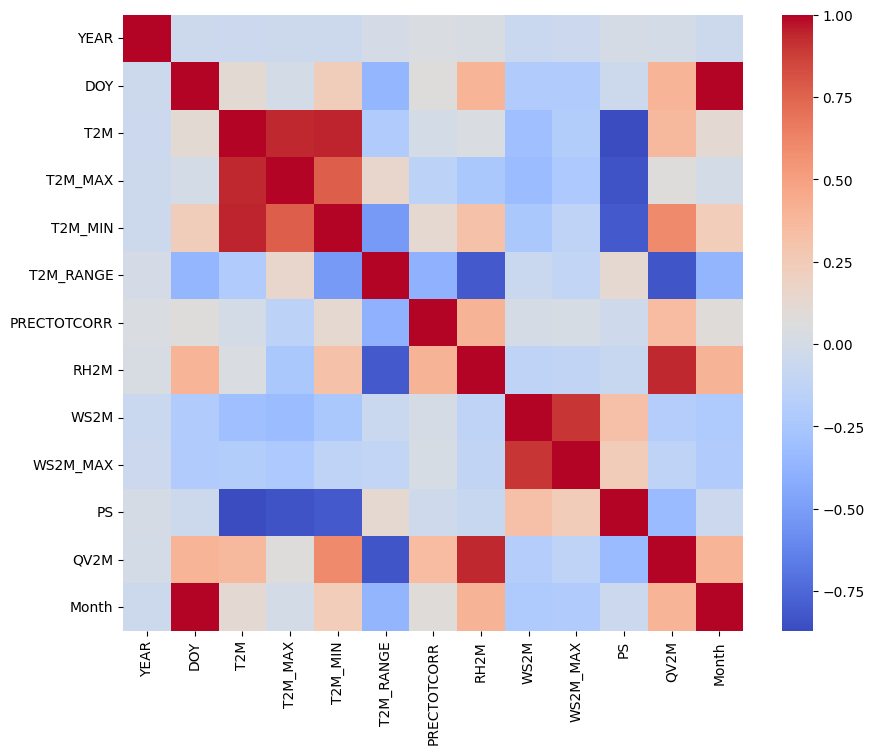

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

### Distribution Analysis

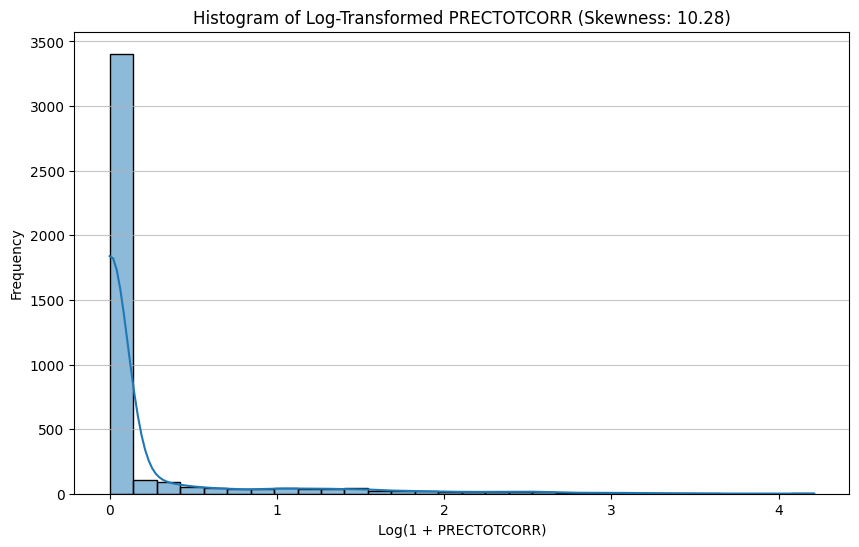

In [10]:
from scipy.stats import skew

# Histogram of PRECTOTCORR
plt.figure(figsize=(10, 6))

skewness_val = skew(df['PRECTOTCORR'].dropna()) # Calculate skewness, dropping NaNs first

if abs(skewness_val) > 1: # A common threshold for high skewness
    sns.histplot(np.log1p(df['PRECTOTCORR']), bins=30, kde=True)
    plt.title(f'Histogram of Log-Transformed PRECTOTCORR (Skewness: {skewness_val:.2f})')
    plt.xlabel('Log(1 + PRECTOTCORR)')
else:
    sns.histplot(df['PRECTOTCORR'], bins=30, kde=True)
    plt.title(f'Histogram of PRECTOTCORR (Skewness: {skewness_val:.2f})')
    plt.xlabel('PRECTOTCORR')

plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### PRECTOTCORR Distribution
The histogram above shows the distribution of `PRECTOTCORR` (total precipitation). Depending on the skewness, a log transformation (specifically `log1p` to handle zero values) was applied to better visualize its distribution. A highly skewed distribution often indicates many days with low or no rainfall, and fewer days with heavy rainfall.

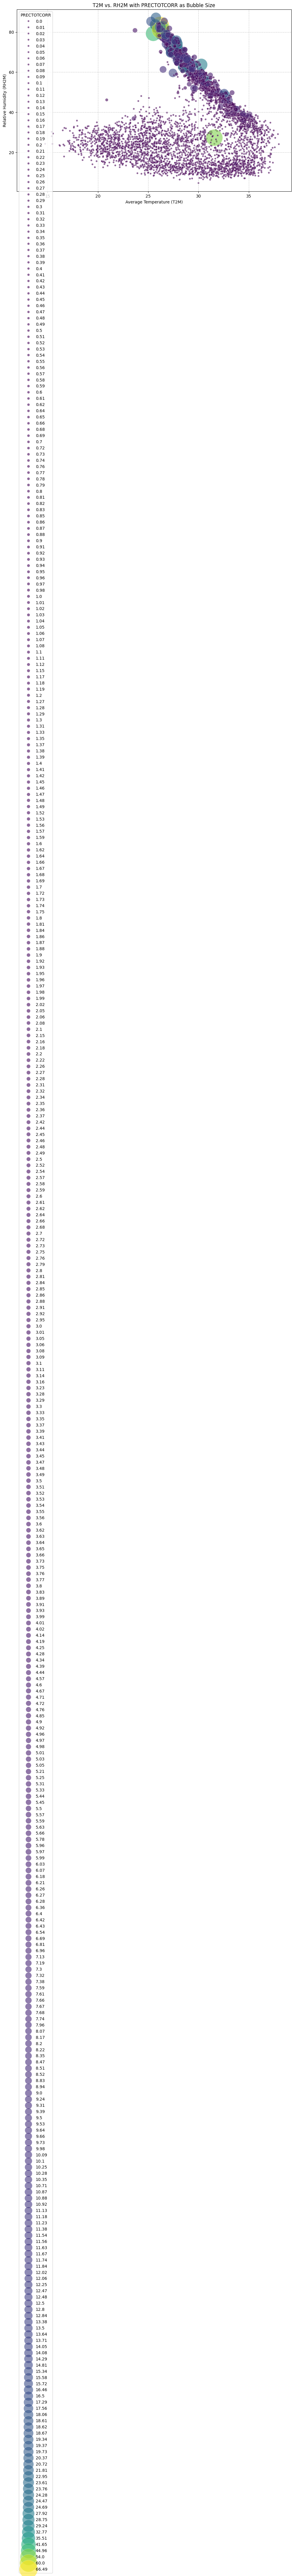

In [11]:
# Bubble chart: T2M vs. RH2M, bubble size = PRECTOTCORR
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR']),
    x='T2M',
    y='RH2M',
    size='PRECTOTCORR', # Scale bubble size by PRECTOTCORR
    sizes=(20, 2000),   # Range of bubble sizes
    hue='PRECTOTCORR',  # Color by PRECTOTCORR
    palette='viridis',  # Color palette
    alpha=0.6,          # Transparency
    legend='full'
)
plt.title('T2M vs. RH2M with PRECTOTCORR as Bubble Size')
plt.xlabel('Average Temperature (T2M)')
plt.ylabel('Relative Humidity (RH2M)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Histogram of PRECTOTCORR: The histogram of PRECTOTCORR (total precipitation) shows a highly skewed distribution, indicating many days with low or no rainfall and fewer days with heavy rainfall. A log transformation was applied to better visualize this distribution, revealing that even with the transformation, the data is concentrated at lower precipitation values.

Correlation Matrix: The heatmap of the correlation matrix visually represents the relationships between numerical variables. Strong positive correlations are observed, for instance, between T2M, T2M_MAX, and T2M_MIN, which is expected as they all relate to temperature. Other variables like RH2M (Relative Humidity) and PRECTOTCORR (Precipitation) might show interesting correlations with each other or with temperature, which can highlight dependencies.

Monthly Rainfall: The bar chart displaying monthly rainfall clearly illustrates a pronounced rainy season. There are specific months that receive significantly higher total precipitation compared to others, suggesting a strong seasonal pattern in rainfall, likely crucial for agricultural planning or water resource management.

Monthly Average Temperature: The line plot of monthly average temperature shows the annual temperature cycle. It helps in identifying the hottest and coldest months and observing the overall trend in temperature fluctuations throughout the year. This pattern often influences local climate conditions and ecological processes